# Applications of APIs
- <b> Social media platforms:  </b> Social media platforms like Facebook, Twitter, and Instagram use APIs to allow developers to access their data and functionality. This allows developers to create applications that can interact with these platforms and provide additional functionality to users.

- <b> E-commerce websites: </b> E-commerce websites like Amazon and eBay use APIs to allow developers to access their product catalogs and other data. This allows developers to create applications that can interact with these platforms and provide additional functionality to users.

- <b> Weather applications: </b> Weather applications like AccuWeather and The Weather Channel use APIs to access weather data from various sources. This allows developers to create applications that can provide users with up-to-date weather information.

- <b> Maps and navigation applications: </b> Maps and navigation applications like Google Maps and Waze use APIs to access location data and other information. This allows developers to create applications that can provide users with directions, traffic updates, and other location-based information.

- <b> Payment gateways: </b> Payment gateways like PayPal and Stripe use APIs to allow developers to access their payment processing functionality. This allows developers to create applications that can process payments securely and efficiently.

- <b> Messaging applications: </b> Messaging applications like WhatsApp and Facebook Messenger use APIs to allow developers to access their messaging functionality. This allows developers to create applications that can interact with these platforms and provide additional functionality to users.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dict_={'a':[11,21,31],'b':[12,22,32]}

In [11]:
df=pd.DataFrame(dict_)
type(df)
df

,a,b
0,11,12
1,21,22
2,31,32


In [12]:
df.head()

,a,b
0,11,12
1,21,22
2,31,32


In [13]:
df.mean()

a    21.0
b    22.0
dtype: float64

## REST APIs

<p>Rest APIs function by sending a <b>request</b>, the request is communicated via HTTP message. The HTTP message usually contains a JSON file. This contains instructions for what operation we would like the service or <b>resource</b> to perform. In a similar manner, API returns a <b>response</b>, via an HTTP message, this response is usually contained within a JSON.</p>
<p>Here, we will use the <a href=https://pypi.org/project/nba-api/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkPY0101ENSkillsNetwork19487395-2021-01-01>NBA API</a> to determine how well the Golden State Warriors performed against the Toronto Raptors. We will use the API to determine the number of points the Golden State Warriors won or lost by for each game. So if the value is three, the Golden State Warriors won by three points. Similarly it the  Golden State Warriors lost  by two points the result will be negative two. The API will handle a lot of the details, such a Endpoints and Authentication. </p>

It's quite simple to use the nba api to make a request for a specific team. We don't require a JSON, all we require is an id. This information is stored locally in the API. We import the module `teams`.


In [14]:
!pip install nba_api

In [15]:
from nba_api.stats.static import teams
import matplotlib.pyplot as plt

In [16]:
def one_dict(list_dict):
    keys=list_dict[0].keys()
    out_dict={key:[] for key in keys}
    for dict_ in list_dict:
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict

In [17]:
nba_teams = teams.get_teams()

In [18]:
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

In [19]:
dict_nba_team=one_dict(nba_teams)
df_teams=pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [20]:
df_warriors=df_teams[df_teams['nickname']=='Warriors']
df_warriors

,id,full_name,abbreviation,nickname,city,state,year_founded
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946


In [21]:
id_warriors=df_warriors[['id']].values[0][0]
# we now have an integer that can be used to request the Warriors information 
id_warriors

np.int64(1610612744)

In [22]:
from nba_api.stats.endpoints import leaguegamefinder

In [23]:
import requests

filename = "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/PY0101EN/Chapter%205/Labs/Golden_State.pkl"

def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)

download(filename, "Golden_State.pkl")


In [24]:
file_name = "Golden_State.pkl"
games = pd.read_pickle(file_name)
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,22019,1610612744,GSW,Golden State Warriors,1521900066,2019-07-12,GSW vs. LAL,L,200,87,...,0.800,13.0,29.0,42.0,13,10.0,3,11.0,21,3.2
1,22019,1610612744,GSW,Golden State Warriors,1521900058,2019-07-10,GSW @ DEN,W,201,73,...,0.867,7.0,27.0,34.0,10,11.0,7,20.0,20,-8.0
2,22019,1610612744,GSW,Golden State Warriors,1521900039,2019-07-08,GSW @ LAL,W,200,88,...,0.621,8.0,29.0,37.0,21,10.0,4,13.0,22,8.0
3,22019,1610612744,GSW,Golden State Warriors,1521900020,2019-07-07,GSW vs. TOR,W,201,80,...,0.923,6.0,37.0,43.0,18,8.0,3,20.0,25,10.0
4,22019,1610612744,GSW,Golden State Warriors,1521900007,2019-07-05,GSW vs. CHA,L,200,85,...,0.889,8.0,28.0,36.0,19,9.0,3,13.0,15,-8.0


In [25]:
games_home=games[games['MATCHUP']=='GSW vs. TOR']
games_away=games[games['MATCHUP']=='GSW @ TOR']

In [26]:
games_home['PLUS_MINUS'].mean()

np.float64(3.730769230769231)

In [27]:
games_away['PLUS_MINUS'].mean()

np.float64(-0.6071428571428571)

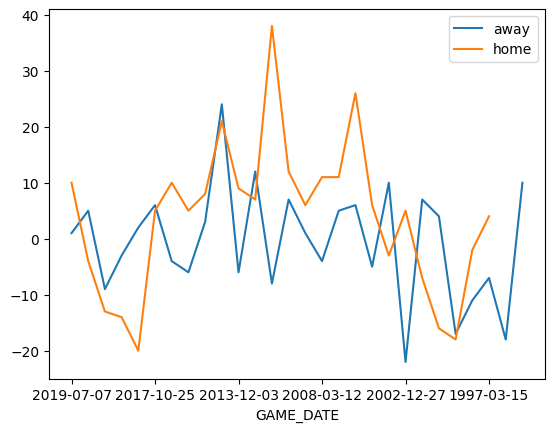

In [28]:
fig, ax = plt.subplots()

games_away.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
games_home.plot(x='GAME_DATE',y='PLUS_MINUS', ax=ax)
ax.legend(["away", "home"])
plt.show()

In [29]:
games_home['PTS'].mean()

games_away['PTS'].mean()

np.float64(102.96428571428571)

# -------------------------------------------

In [30]:
import requests

In [31]:
import os 
from PIL import Image
from IPython.display import IFrame

In [34]:
url='https://www.google.com/'
r=requests.get(url)

In [35]:
r.status_code

200

In [36]:
print(r.request.headers)

{'User-Agent': 'python-requests/2.32.5', 'Accept-Encoding': 'gzip, deflate, zstd', 'Accept': '*/*', 'Connection': 'keep-alive'}


In [37]:
print("request body:", r.request.body)

request body: None


In [38]:
header=r.headers
print(r.headers)

{'Content-Type': 'text/html; charset=ISO-8859-1', 'Date': 'Fri, 29 May 2026 06:39:35 GMT', 'Expires': '-1', 'Cache-Control': 'private, max-age=0', 'Content-Security-Policy-Report-Only': "object-src 'none';base-uri 'self';script-src 'nonce-Ia98p49yOc9nKkJwB7oDsQ' 'strict-dynamic' 'report-sample' 'unsafe-eval' 'unsafe-inline' https: http:;report-uri https://csp.withgoogle.com/csp/gws/other-hp", 'Accept-CH': 'Sec-CH-Prefers-Color-Scheme', 'P3P': 'CP="This is not a P3P policy! See g.co/p3phelp for more info."', 'Content-Encoding': 'gzip', 'Server': 'gws', 'X-XSS-Protection': '0', 'X-Frame-Options': 'SAMEORIGIN', 'Set-Cookie': '__Secure-STRP=ANmZwa15A5FHCSRSOKVAcWEals3sZ7QJK5gWthpyf1mmnb1R-RYZU-PeomwsJS-KXDhNGjZBNfYZn4s2pSXGjrwFBkgMQN2SRA; expires=Fri, 29-May-2026 06:44:35 GMT; path=/; domain=.google.com; Secure; SameSite=strict, AEC=AaJma5uXmKlMfXrM1wp3raVOD1ngjYrgtbFT7ZT7h07Je7-fm-WebuqWtQ; expires=Wed, 25-Nov-2026 06:39:35 GMT; path=/; domain=.google.com; Secure; HttpOnly; SameSite=lax, 

In [39]:
header['Date']

'Fri, 29 May 2026 06:39:35 GMT'

In [40]:
header['Content-Type']

'text/html; charset=ISO-8859-1'

In [41]:
 r.encoding

'ISO-8859-1'

In [42]:
r.text[0:100]

'<!doctype html><html itemscope="" itemtype="http://schema.org/WebPage" lang="en-IN"><head><meta cont'

In [43]:
url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/IDSNlogo.png'

In [44]:
r=requests.get(url)

In [45]:
print(r.headers)

{'Date': 'Fri, 29 May 2026 06:41:05 GMT', 'X-Clv-Request-Id': '8b2efaba-fe54-4332-9120-7e9f76ccd31a', 'Server': 'Cleversafe', 'X-Clv-S3-Version': '2.5', 'Accept-Ranges': 'bytes', 'x-amz-request-id': '8b2efaba-fe54-4332-9120-7e9f76ccd31a', 'ETag': '"8bb44578fff8fdcc3d2972be9ece0164"', 'Content-Type': 'image/png', 'Last-Modified': 'Wed, 16 Nov 2022 03:32:41 GMT', 'Content-Length': '78776'}


In [46]:
r.headers['Content-Type']

'image/png'

In [47]:
path=os.path.join(os.getcwd(),'image.png')

In [48]:
with open(path,'wb') as f:
    f.write(r.content)

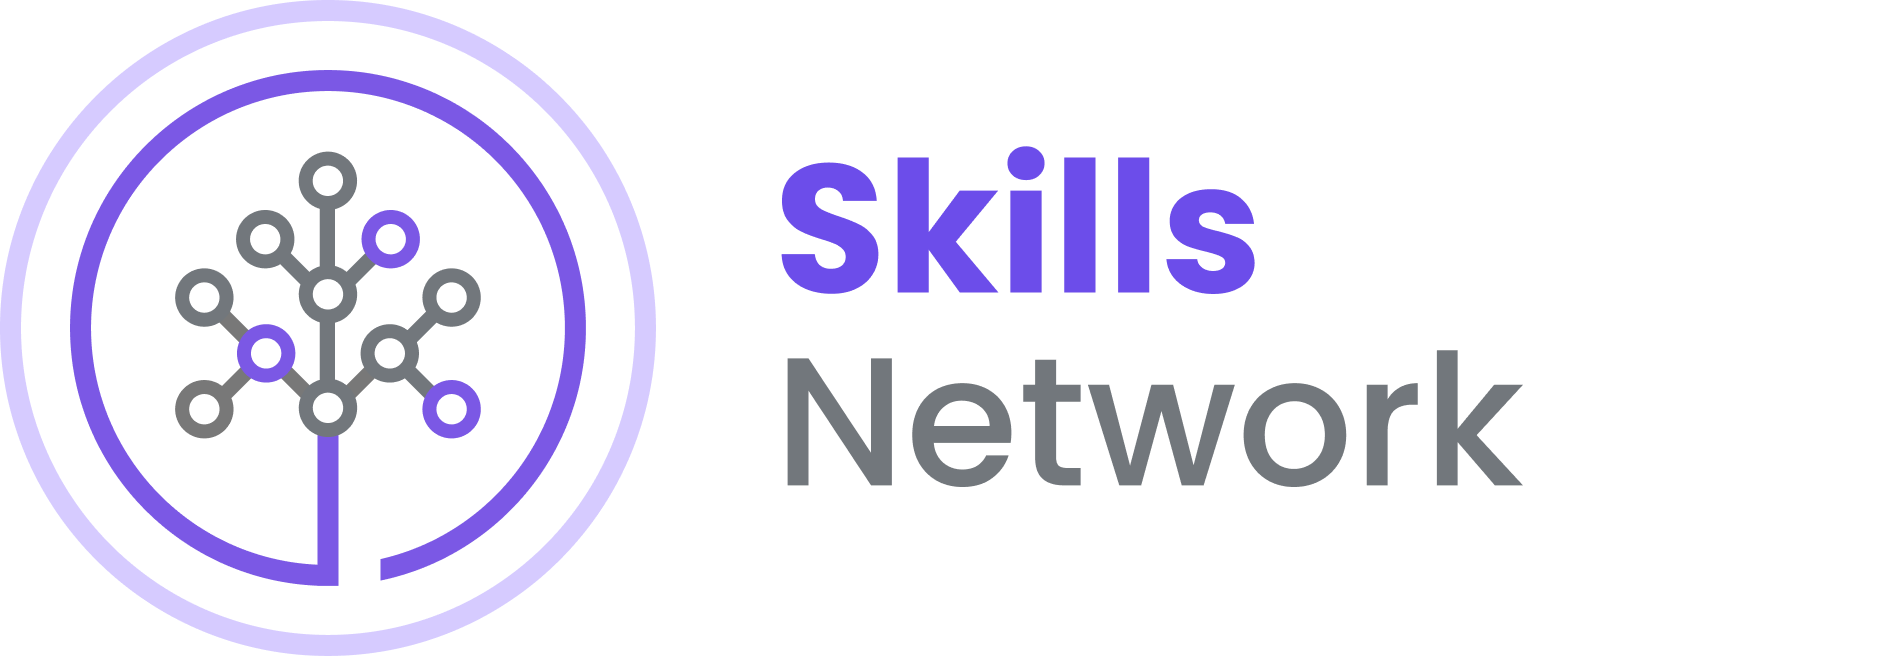

In [49]:
Image.open(path)

# DIFFERENT FILE FORMATS

## Data Engineering Process

There are several steps in Data Engineering process.

1.  **Extract** - Data extraction is getting data from multiple sources. Ex. Data extraction from a website using Web scraping or gathering information from the data that are stored in different formats(JSON, CSV, XLSX etc.).

2.  **Transform** - Transforming the data means removing the data that we don't need for further analysis and converting the data in the format that all the data from the multiple sources is in the same format.

3.  **Load** - Loading the data inside a data warehouse. Data warehouse essentially contains large volumes of data that are accessed to gather insights.

## Working with different file formats


In the real-world, people rarely get neat tabular data. Thus, it is mandatory for any data scientist (or data engineer) to be aware of different file formats, common challenges in handling them and the best, most efficient ways to handle this data in real life. 

#### File Format

<p>A file format is a standard way in which information is encoded for storage in a file. First, the file format specifies whether the file is a binary or ASCII file. Second, it shows how the information is organized. For example, the comma-separated values (CSV) file format stores tabular data in plain text.

To identify a file format, you can usually look at the file extension to get an idea. For example, a file saved with name "Data" in "CSV" format will appear as **Data.csv**. By noticing the **.csv** extension, we can clearly identify that it is a **CSV** file and the data is stored in a tabular format.</p>

## Comma-separated values (CSV) file format

The **Comma-separated values** file format falls under a spreadsheet file format.

In a spreadsheet file format, data is stored in cells. Each cell is organized in rows and columns. A column in the spreadsheet file can have different types. For example, a column can be of string type, a date type, or an integer type.

Each line in CSV file represents an observation, or commonly called a record. Each record may contain one or more fields which are separated by a comma.

### Reading data from CSV in Python
The **Pandas** Library is a useful tool that enables us to read various datasets into a Pandas data frame

Let us look at how to read a CSV file in Pandas Library.

We use **pandas.read_csv()** function to read the csv file. In the parentheses, we put the file path along with a quotation mark as an argument, so that pandas will read the file into a data frame from that address. The file path can be either a URL or your local file address.

In [2]:
pip install piplite

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement piplite (from versions: none)
ERROR: No matching distribution found for piplite


In [2]:
import piplite
await piplite.install(['seaborn', 'lxml', 'openpyxl'])

import pandas as pd

ModuleNotFoundError: No module named 'piplite'

In [3]:
from pyodide.http import pyfetch

filename = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0101EN-SkillsNetwork/labs/Module%205/data/addresses.csv"

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

await download(filename, "addresses.csv")

df = pd.read_csv("addresses.csv", header=None)

ModuleNotFoundError: No module named 'pyodide'